In [1]:
import polars as pl

In [2]:
dfl=pl.read_csv('../data/raw/complaints.csv', null_values=["N/A", "NA", "null", ""])
dfl

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Incorrect information on your …","""Information belongs to someone…",null,null,"""Experian Information Solutions…","""FL""","""32092""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195687
"""2025-06-20""","""Debt collection""","""Telecommunications debt""","""Attempts to collect debt not o…","""Debt is not yours""",null,"""Company can't verify or disput…","""Eastern Account Systems of Con…","""FL""","""342XX""",null,null,"""Web""","""2025-06-20""","""Closed with explanation""","""Yes""",null,14195688
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Improper use of your report""","""Reporting company used your re…",null,null,"""TRANSUNION INTERMEDIATE HOLDIN…","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195689
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Improper use of your report""","""Reporting company used your re…",null,null,"""Experian Information Solutions…","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195690
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Incorrect information on your …","""Account status incorrect""",null,null,"""Experian Information Solutions…","""IL""","""60628""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195692
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2016-09-08""","""Credit reporting""",null,"""Unable to get credit report/cr…","""Problem getting my free annual…",null,null,"""EQUIFAX, INC.""","""FL""","""32853""",null,"""Consent not provided""","""Web""","""2016-09-08""","""Closed with explanation""","""Yes""","""Yes""",2102374
"""2022-06-06""","""Credit reporting, credit repai…","""Credit reporting""","""Problem with a credit reportin…","""Their investigation did not fi…",null,null,"""EQUIFAX, INC.""","""CA""","""93638""",null,"""Consent not provided""","""Web""","""2022-06-06""","""Closed with explanation""","""Yes""",null,5637858
"""2016-07-14""","""Credit reporting""",null,"""Unable to get credit report/cr…","""Problem getting report or cred…",null,null,"""EQUIFAX, INC.""","""NJ""","""08620""","""Older American, Servicemember""",null,"""Phone""","""2016-07-14""","""Closed with explanation""","""Yes""","""No""",2012835


In [3]:
dfl.columns

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Consumer consent provided?',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Consumer disputed?',
 'Complaint ID']

In [4]:
dfl.dtypes

[String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 String,
 Int64]

In [5]:
dfl.is_empty()

False

In [6]:
dfl.null_count()

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,235295,6,839522,6629041,4770207,0,54516,30228,8981029,1649561,0,0,20,0,8841498,0


In [7]:
dfl.shape

(9609797, 18)

In [8]:
dfl['Company response to consumer'].value_counts()

Company response to consumer,count
str,u32
"""Closed without relief""",17868
"""Closed with non-monetary relie…",3224078
null,20
"""Untimely response""",16679
"""Closed with explanation""",5487712
"""Closed with monetary relief""",179894
"""In progress""",660631
"""Closed""",17611
"""Closed with relief""",5304


In [9]:
# import pandas as pd

In [10]:
# df=pd.read_csv('../data/raw/complaints.csv')

In [11]:
# df.head()

In [12]:
# df.dtypes

In [13]:
# df.isna().sum()

In [14]:
dfl.null_count()

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,235295,6,839522,6629041,4770207,0,54516,30228,8981029,1649561,0,0,20,0,8841498,0


In [15]:
# colst=[col for col in dfl.columns if dfl.schema[col] == pl.String]
# for c in colst:
#     print(dfl.select(
#         pl.col(c).str.len_chars().sum()
#     ))

In [16]:
dfl['Consumer complaint narrative'].str.len_chars().sum()

2980039508

In [8]:
import polars as pl

In [9]:
pl.Config.set_tbl_rows(50)          
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [18]:
grouped_lengths = dfl.group_by("Product").agg(
    pl.col('Consumer complaint narrative').str.len_chars().sum()
)

print(grouped_lengths)

shape: (21, 2)
┌─────────────────────────────────────────────────────────────┬──────────────────────────────┐
│ Product                                                     ┆ Consumer complaint narrative │
│ ---                                                         ┆ ---                          │
│ str                                                         ┆ u32                          │
╞═════════════════════════════════════════════════════════════╪══════════════════════════════╡
│ Money transfers                                             ┆ 1726305                      │
│ Virtual currency                                            ┆ 15043                        │
│ Credit reporting, credit repair services, or other personal ┆ 717201799                    │
│ consumer reports                                            ┆                              │
│ Credit card or prepaid card                                 ┆ 132494492                    │
│ Mortgage                         

In [20]:
product_complain_distribution=dfl.group_by('Product').len().sort('len', descending=True)
print(product_complain_distribution)

shape: (21, 2)
┌──────────────────────────────────────────────────────────────────────────────┬─────────┐
│ Product                                                                      ┆ len     │
│ ---                                                                          ┆ ---     │
│ str                                                                          ┆ u32     │
╞══════════════════════════════════════════════════════════════════════════════╪═════════╡
│ Credit reporting or other personal consumer reports                          ┆ 4834855 │
│ Credit reporting, credit repair services, or other personal consumer reports ┆ 2163857 │
│ Debt collection                                                              ┆ 799197  │
│ Mortgage                                                                     ┆ 422254  │
│ Checking or savings account                                                  ┆ 291178  │
│ Credit card                                                              

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [22]:
%matplotlib inline


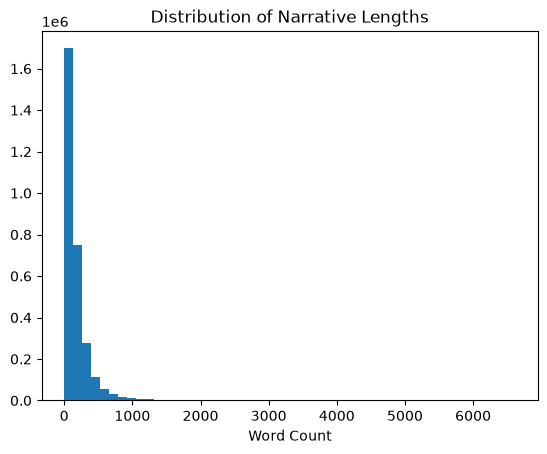

In [ ]:

dfl = dfl.with_columns(
    pl.col("Consumer complaint narrative")
    .str.split(by=" ")
    .list.len()
    .alias("word_count")
)

plt.hist(dfl["word_count"].drop_nulls().to_list(), bins=50)
plt.xlabel("Word Count")
plt.title("Distribution of Narrative Lengths")
plt.show()

very_short = dfl.filter(pl.col("word_count") < 10)
very_long = dfl.filter(pl.col("word_count") > 1000)

In [26]:
stats = dfl.select([
    pl.col("Consumer complaint narrative").is_null().sum().alias("missing_narrative"),
    pl.col("Consumer complaint narrative").is_not_null().sum().alias("present_narrative")
])
print(stats)

shape: (1, 2)
┌───────────────────┬───────────────────┐
│ missing_narrative ┆ present_narrative │
│ ---               ┆ ---               │
│ u32               ┆ u32               │
╞═══════════════════╪═══════════════════╡
│ 6629041           ┆ 2980756           │
└───────────────────┴───────────────────┘


In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.eda_cfpb import InitialEda

In [4]:
ie=InitialEda('../data/raw/complaints.csv')


In [5]:
ie.load_data()

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Incorrect information on your …","""Information belongs to someone…",null,null,"""Experian Information Solutions…","""FL""","""32092""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195687
"""2025-06-20""","""Debt collection""","""Telecommunications debt""","""Attempts to collect debt not o…","""Debt is not yours""",null,"""Company can't verify or disput…","""Eastern Account Systems of Con…","""FL""","""342XX""",null,null,"""Web""","""2025-06-20""","""Closed with explanation""","""Yes""",null,14195688
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Improper use of your report""","""Reporting company used your re…",null,null,"""TRANSUNION INTERMEDIATE HOLDIN…","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195689
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Improper use of your report""","""Reporting company used your re…",null,null,"""Experian Information Solutions…","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195690
"""2025-06-20""","""Credit reporting or other pers…","""Credit reporting""","""Incorrect information on your …","""Account status incorrect""",null,null,"""Experian Information Solutions…","""IL""","""60628""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195692
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2016-09-08""","""Credit reporting""",null,"""Unable to get credit report/cr…","""Problem getting my free annual…",null,null,"""EQUIFAX, INC.""","""FL""","""32853""",null,"""Consent not provided""","""Web""","""2016-09-08""","""Closed with explanation""","""Yes""","""Yes""",2102374
"""2022-06-06""","""Credit reporting, credit repai…","""Credit reporting""","""Problem with a credit reportin…","""Their investigation did not fi…",null,null,"""EQUIFAX, INC.""","""CA""","""93638""",null,"""Consent not provided""","""Web""","""2022-06-06""","""Closed with explanation""","""Yes""",null,5637858
"""2016-07-14""","""Credit reporting""",null,"""Unable to get credit report/cr…","""Problem getting report or cred…",null,null,"""EQUIFAX, INC.""","""NJ""","""08620""","""Older American, Servicemember""",null,"""Phone""","""2016-07-14""","""Closed with explanation""","""Yes""","""No""",2012835


In [6]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Tags', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Consumer disputed?', String), ('Complaint ID', Int64)])


The missing data

shape: (18, 2)
┌──────────────────────────────┬──────────┐
│ column                       ┆ column_0 │
│ ---                          ┆ ---      │
│ str                          ┆ u32      │
╞══════════════════════════════╪══════════╡
│ Date received                ┆ 0        │
│ Product                      ┆ 0        │
│ Sub-product                  ┆ 235295   │
│ Issue                        ┆ 6        │
│ Sub-issue    

In [7]:
ie.analyze_product_distribution()


Complaint Distribution by Product:
shape: (21, 2)
┌─────────────────────────────────┬─────────┐
│ Product                         ┆ len     │
│ ---                             ┆ ---     │
│ str                             ┆ u32     │
╞═════════════════════════════════╪═════════╡
│ Credit reporting or other pers… ┆ 4834855 │
│ Credit reporting, credit repai… ┆ 2163857 │
│ Debt collection                 ┆ 799197  │
│ Mortgage                        ┆ 422254  │
│ Checking or savings account     ┆ 291178  │
│ …                               ┆ …       │
│ Payday loan                     ┆ 5541    │
│ Money transfers                 ┆ 5354    │
│ Debt or credit management       ┆ 5047    │
│ Other financial service         ┆ 1058    │
│ Virtual currency                ┆ 18      │
└─────────────────────────────────┴─────────┘


Product,len
str,u32
"""Credit reporting or other pers…",4834855
"""Credit reporting, credit repai…",2163857
"""Debt collection""",799197
"""Mortgage""",422254
"""Checking or savings account""",291178
…,…
"""Payday loan""",5541
"""Money transfers""",5354
"""Debt or credit management""",5047


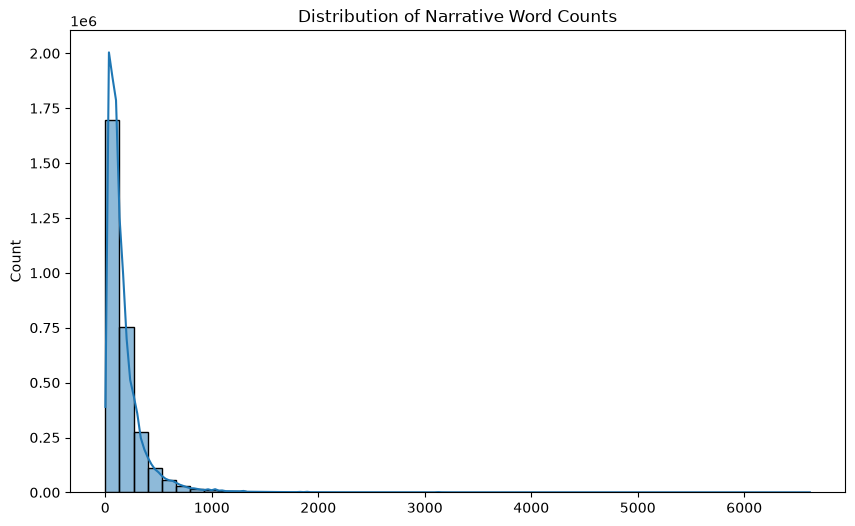

statistic,word_count
str,f64
"""count""",2.980756e6
"""null_count""",6.629041e6
"""mean""",175.865631
"""std""",226.094433
"""min""",1.0
"""25%""",59.0
"""50%""",114.0
"""75%""",210.0
"""max""",6617.0


In [8]:
ie.analyze_narrative_lengths()

In [9]:
ie.count_narrative_presence()


Narrative Presence Summary:
shape: (1, 2)
┌─────────┬─────────┐
│ missing ┆ present │
│ ---     ┆ ---     │
│ u32     ┆ u32     │
╞═════════╪═════════╡
│ 6629041 ┆ 2980756 │
└─────────┴─────────┘


missing,present
u32,u32
6629041,2980756


In [10]:
ie.clean_data()

2026-06-19 14:01:02,897 - INFO - Data cleaned. New shape: (464010, 21)


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,Product_Lower,Product_Category
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,u32,str,str
"""2025-06-13""","""Credit card""","""Store credit card""","""Getting a credit card""","""Card opened without my consent…","""A XXXX XXXX card was opened un…","""Company has responded to the c…","""CITIBANK, N.A.""","""TX""","""78230""","""Servicemember""","""Consent provided""","""Web""","""2025-06-13""","""Closed with non-monetary relie…","""Yes""",null,14069121,92,"""credit card""","""Credit Card"""
"""2025-06-13""","""Checking or savings account""","""Checking account""","""Managing an account""","""Deposits and withdrawals""","""I made the mistake of using my…","""Company has responded to the c…","""WELLS FARGO & COMPANY""","""ID""","""83815""",null,"""Consent provided""","""Web""","""2025-06-13""","""Closed with explanation""","""Yes""",null,14061897,109,"""checking or savings account""","""Savings Account"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or…","""Other features, terms, or prob…","""Other problem""","""Dear CFPB, I have a secured cr…","""Company has responded to the c…","""CITIBANK, N.A.""","""NY""","""11220""",null,"""Consent provided""","""Web""","""2025-06-13""","""Closed with monetary relief""","""Yes""",null,14047085,154,"""credit card""","""Credit Card"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or…","""Incorrect information on your …","""Account information incorrect""","""I have a Citi rewards cards. T…","""Company has responded to the c…","""CITIBANK, N.A.""","""IL""","""60067""",null,"""Consent provided""","""Web""","""2025-06-12""","""Closed with explanation""","""Yes""",null,14040217,233,"""credit card""","""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or…","""Problem with a purchase shown …","""Credit card company isn't reso…","""b'I am writing to dispute the …","""Company has responded to the c…","""CITIBANK, N.A.""","""TX""","""78413""","""Older American""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",null,13968411,456,"""credit card""","""Credit Card"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2022-06-06""","""Money transfer, virtual curren…","""Domestic (US) money transfer""","""Confusing or missing disclosur…",null,"""I moved into XXXX XXXX XXXX X…","""Company believes complaint rep…","""Entrata Inc.""","""CA""","""922XX""",null,"""Consent provided""","""Web""","""2022-06-06""","""Closed with monetary relief""","""Yes""",null,5638610,388,"""money transfer, virtual curren…","""Money Transfer"""
"""2022-08-19""","""Payday loan, title loan, or pe…","""Installment loan""","""Problem when making payments""",null,"""Omni financial loan. Paid for …","""Company believes the complaint…","""Siggi LLC""","""VA""","""20136""","""Servicemember""","""Consent provided""","""Web""","""2022-08-19""","""Closed with explanation""","""Yes""",null,5896172,7,"""payday loan, title loan, or pe…","""Personal Loan"""
"""2022-08-19""","""Money transfer, virtual curren…","""International money transfer""","""Other transaction problem""",null,"""Hello, I'm an XXXX of XXXX XX…","""Company has responded to the c…","""CITIBANK, N.A.""",null,"""XXXXX""",null,"""Consent provided""","""Web""","""2022-08-19""","""Closed with explanation""","""Yes""",null,5896060,208,"""money transfer, virtual curren…","""Money Transfer"""


In [11]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Tags', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Consumer disputed?', String), ('Complaint ID', Int64), ('word_count', UInt32), ('Product_Lower', String), ('Product_Category', String)])


The missing data

shape: (21, 2)
┌────────────────────┬──────────┐
│ column             ┆ column_0 │
│ ---                ┆ ---      │
│ str                ┆ u32      │
╞════════════════════╪══════════╡
│ Date received      ┆ 0        │
│ Product            ┆ 0        │
│ Sub-product        ┆ 20619    │
│ Issue              ┆ 0        │
│ Sub-issue          ┆ 1

In [12]:
cleaned=ie.clean_narratives_text()

2026-06-19 14:01:14,646 - INFO - Narratives successfully cleaned and normalized.



--- NLP EDA: Cleaned Data ---

[Class Balance]
 shape: (4, 2)
┌──────────────────┬────────┐
│ Product_Category ┆ len    │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ Credit Card      ┆ 197126 │
│ Savings Account  ┆ 140319 │
│ Money Transfer   ┆ 98685  │
│ Personal Loan    ┆ 27880  │
└──────────────────┴────────┘

Total Unique Vocabulary Size: 236184
Potential Outliers (<5 or >1000 words): 5762


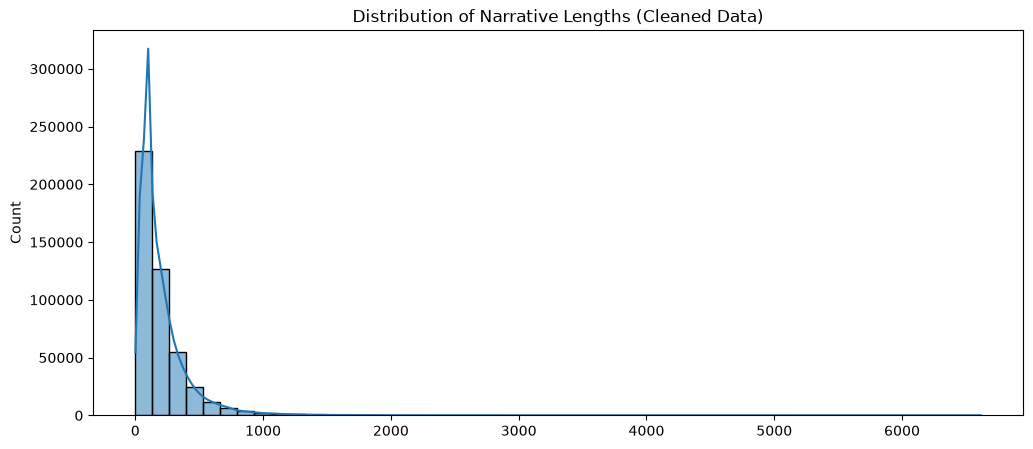

In [13]:
ie.perform_text_eda(stage_name='Cleaned Data')